In [1]:
from sklearn.metrics import mean_squared_error
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Input, Model 
from tensorflow.keras.layers import LSTM, Dense, Concatenate, TimeDistributed
import os
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
import random

import datetime
from check_stationarity import load_train_data
from feature_selection import combine_qd_and_md_as_qd, remove_highly_correlated_features, lasso_feature_selection, tree_based_feature_selection, rfe_feature_selection




In [2]:
md_train_stationary, qd_train_stationary = load_train_data()

selected_features, _ = rfe_feature_selection(combine_qd_and_md_as_qd(qd_train_stationary, md_train_stationary), n_features= 15)
selected_features

monthly_features = [feature for feature in selected_features if feature in md_train_stationary.columns]
quarterly_features = [feature for feature in selected_features if feature in qd_train_stationary.columns] + ["GDPC1"]

train_md = md_train_stationary[monthly_features]
train_qd = qd_train_stationary[quarterly_features]

print(train_md)
print(train_qd)


Top Features Selected by RFE:
['TARESAx', 'ULCNFB', 'OPHPBS', 'NWPIx', 'COMPRNFB', 'RCPHBS', 'OPHNFB', 'A014RE1Q156NBEA', 'PCESVx', 'USPRIV', 'DPIC96', 'ULCBS', 'PERMIT', 'INDPRO', 'HOUST']
              PERMIT    INDPRO     HOUST
date                                    
1960-04-01  6.923629 -0.007956  7.161622
1960-05-01  6.958448 -0.001143  7.147559
1960-06-01  6.864848 -0.012652  7.128496
1960-07-01  6.906755 -0.003481  7.087574
1960-08-01  6.901737 -0.001159  7.203406
...              ...       ...       ...
2014-08-01  6.953684 -0.001589  6.891626
2014-09-01  6.981935  0.003011  6.930495
2014-10-01  6.997596  0.000188  6.979145
2014-11-01  6.965080  0.006165  6.908755
2014-12-01  6.977281  0.000167  6.978214

[657 rows x 3 columns]
             TARESAx    ULCNFB    OPHPBS      NWPIx  COMPRNFB    RCPHBS  \
date                                                                      
1960-06-01  0.008067  0.022152 -0.021124  -0.722286  0.000453 -0.010065   
1960-09-01 -0.007862 -0.000

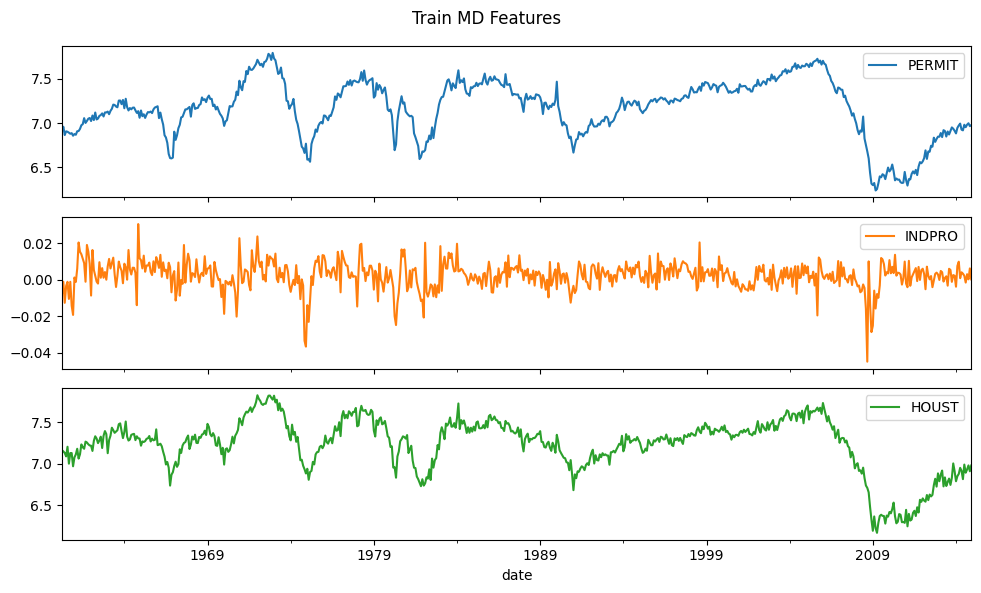

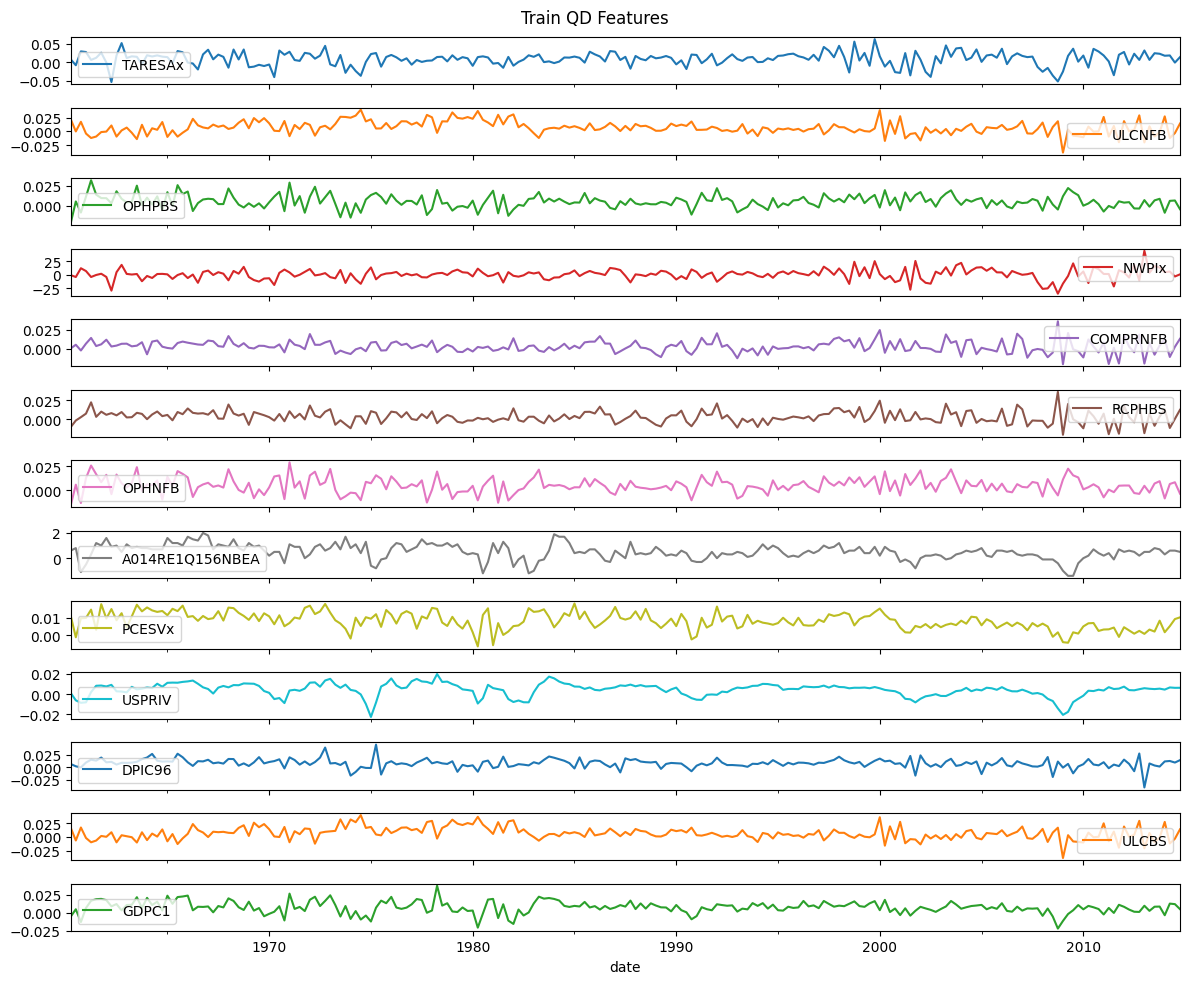

In [3]:
# Plot train_md features
train_md.plot(subplots=True, figsize=(10, 6), title="Train MD Features", legend=True)
plt.tight_layout()
plt.show()

# Plot train_qd features
train_qd.plot(subplots=True, figsize=(12, 10), title="Train QD Features", legend=True)
plt.tight_layout()
plt.show()

Boxcox tranfsformation

C:\Users\giada\AppData\Local\Temp\ipykernel_11120\3964962261.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_md[feature] = apply_boxcox(train_md[feature])


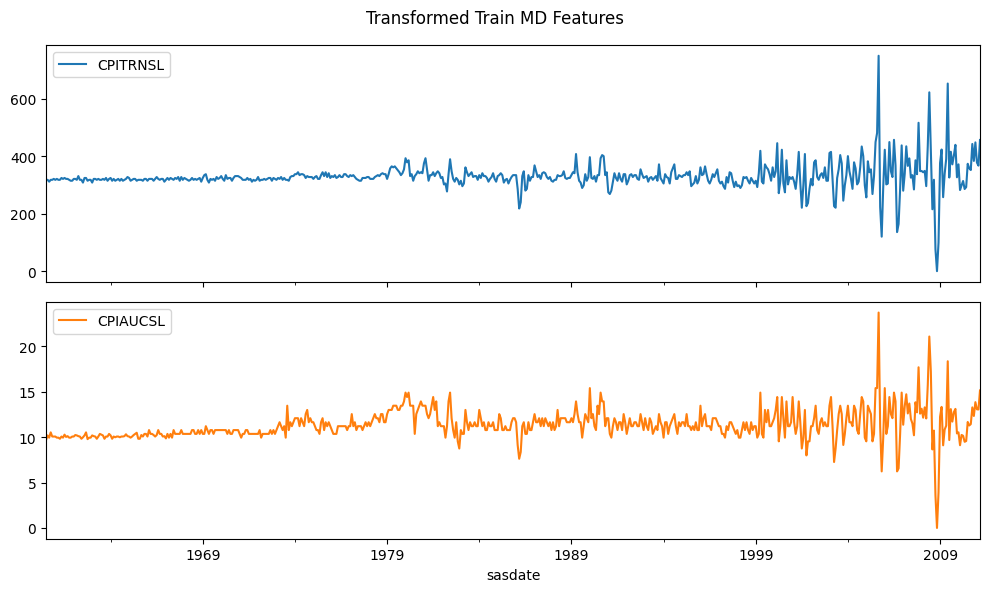

In [79]:
from scipy.stats import boxcox
import numpy as np
if True:
    # Function to apply Box-Cox transformation
    def apply_boxcox(series):
        # Shift the series if it contains non-positive values
        if (series <= 0).any():
            series = series - series.min() + 1
        transformed, _ = boxcox(series)
        return transformed

    # Apply Box-Cox transformation to non-stationary features
    non_stationary_features = ['CPIAUCSL', 'CPITRNSL']  # Replace with actual non-stationary features
    for feature in non_stationary_features:
        train_md[feature] = apply_boxcox(train_md[feature])

    # Re-plot the transformed features
    train_md.plot(subplots=True, figsize=(10, 6), title="Transformed Train MD Features", legend=True)
    plt.tight_layout()
    plt.show()

Index(['HNOREMQ027Sx', 'OPHPBS', 'TABSHNOx', 'IMPGSC1', 'TARESAx', 'OUTNFB',
       'PCDGx', 'GCEC1', 'PCESVx', 'PCNDx', 'GPDIC1', 'HOABS', 'EXPGSC1',
       'GDPC1'],
      dtype='object')
True
Index(['HNOREMQ027Sx', 'OPHPBS', 'TABSHNOx', 'IMPGSC1', 'TARESAx', 'OUTNFB',
       'PCDGx', 'GCEC1', 'PCESVx', 'PCNDx', 'GPDIC1', 'HOABS', 'EXPGSC1'],
      dtype='object')
len(train_qd)=203
len(train_md)=609
len(train_md.iloc[::3])=203
len(exogenous_features)=203


c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\giada\AppData\Local\Temp\ipykernel_11120\3677126800.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To acce

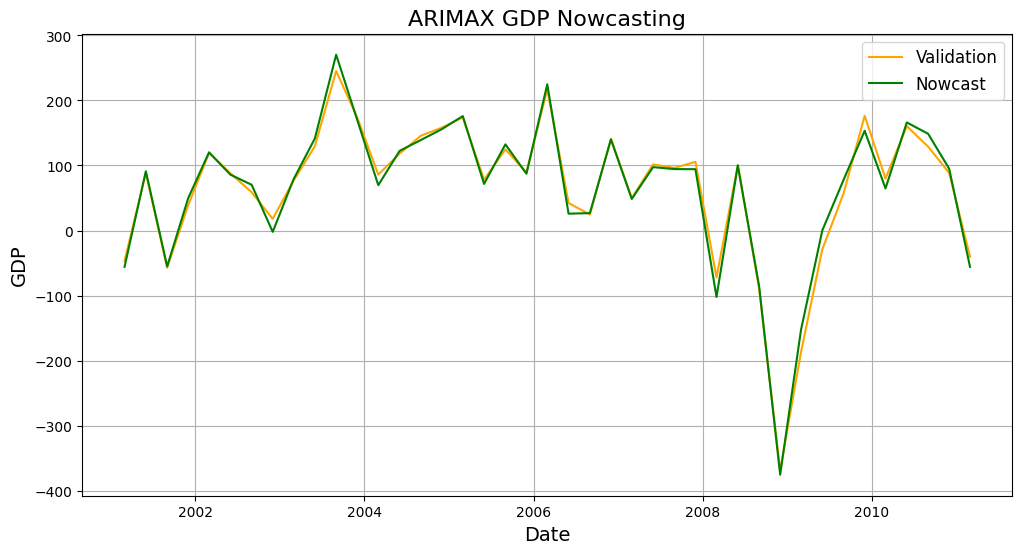

Mean Squared Error: 179.71512329802752


In [66]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.special import inv_boxcox

print(train_qd.columns)
print("GDPC1" in train_qd.columns)
print(train_qd.drop("GDPC1", axis=1).columns)

# Define the exogenous variables (e.g., other features from train_md or train_qd)
exogenous_features = pd.concat([train_md.iloc[2::3], train_qd.drop("GDPC1", axis=1)], axis=1)# Replace with actual exogenous variables
print(f"{len(train_qd)=}")
print(f"{len(train_md)=}")
print(f"{len(train_md.iloc[::3])=}")
print(f"{len(exogenous_features)=}")
assert len(train_qd) == len(exogenous_features), "Length of exogenous_features was expected to match length of train_qd" 

amount_of_data = len(train_qd)
split_at = int(amount_of_data * 0.8)

exogenous_train = exogenous_features.iloc[:split_at]
exogenous_val = exogenous_features.iloc[split_at:]

# Split train and validation sets for the target variable
y_train = train_qd["GDPC1"].iloc[:split_at]
val = train_qd["GDPC1"].iloc[split_at:]

# Build the ARIMAX model
model = SARIMAX(y_train, exog=exogenous_train, order=(2, 0, 9)).fit()

# Forecast using the ARIMAX model
forecasts = []

# Copy the training data to use for recursive forecasting
history = list(y_train)  # Convert to a list for appending new values
exog_history = exogenous_train.values.tolist()

# Recursive forecasting
for i in range(len(val)):
    # Forecast the next value
    exog_next = exogenous_val.iloc[i].values.reshape(1, -1)
    forecast_value = model.forecast(steps=1, exog=exog_next)[0]

    # Append the forecasted value to the forecasts list
    forecasts.append(forecast_value)

    # Update the history with the true value and exogenous variable
    history.append(val.iloc[i])
    exog_history.append(exogenous_val.iloc[i].values)

    # Refit the model with updated history
    model = SARIMAX(history, exog=exog_history, order=(2, 1, 9)).fit(disp=False)
    # model.append([val.iloc[i]], refit=False)


# Plot the forecasts
plt.figure(figsize=(12, 6))
plt.plot(val.index, val, label='Validation', color='orange')
plt.plot(val.index, forecasts, label='Nowcast', color='green')
plt.title('ARIMAX GDP Nowcasting', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('GDP', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Calculate Mean Squared Error
mse = mean_squared_error(val, forecasts)
print("Mean Squared Error:", mse)

amount_of_data=203
split_at=162
len(qd)=203
len(val_qd)=41
len(previous_qd_values)=41
len(forecasts)=41


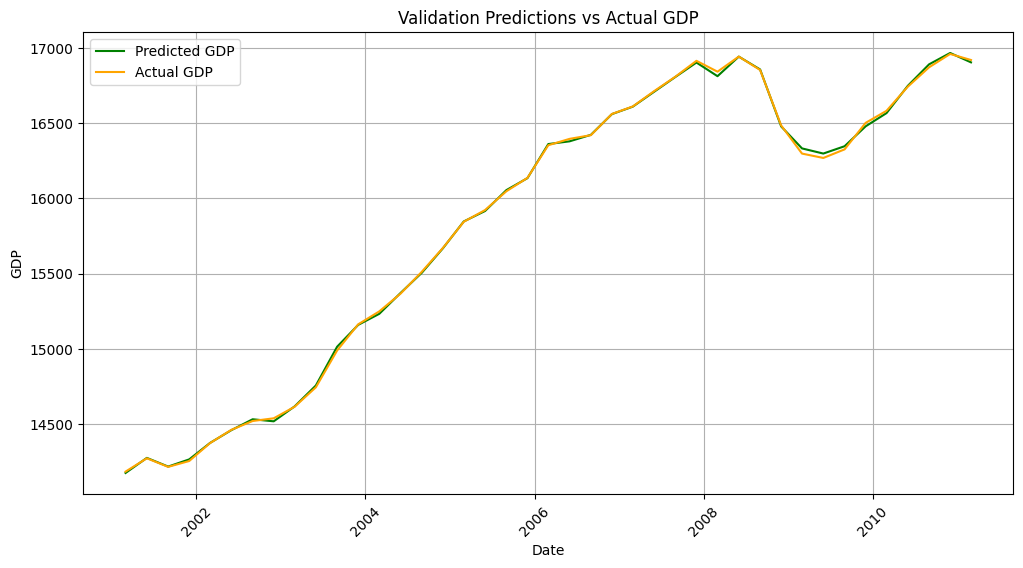

Mean Squared Error: 179.7151232980298


In [77]:
def plot_rescaled():
    qd = pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d").iloc[2:]["GDPC1"]
    qd.index = pd.to_datetime(qd.index, format="%m/%d/%Y")
    qd = qd.loc[qd_train_stationary.index]
    val_qd = qd.iloc[split_at:]
    previous_qd_values = qd.iloc[split_at-1:-1].values

    print(f"{amount_of_data=}")
    print(f"{split_at=}")
    print(f"{len(qd)=}")
    print(f"{len(val_qd)=}")
    print(f"{len(previous_qd_values)=}")
    print(f"{len(forecasts)=}")

    rescaled_forecast = np.array(forecasts).reshape(-1) + previous_qd_values

    plt.figure(figsize=(12, 6))
    plt.plot(val_qd.index, rescaled_forecast, label="Predicted GDP", color="green")
    plt.plot(val_qd.index, val_qd.values, label="Actual GDP", color="orange")
    plt.title("Validation Predictions vs Actual GDP")
    plt.xlabel("Date")
    plt.ylabel("GDP")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)    
    plt.show()

    mse = mean_squared_error(val_qd, rescaled_forecast)
    print("Mean Squared Error:", mse)

plot_rescaled()
